# Case 11

# Does this repo's original configuration change Case 1's qualitative result?

## Purpose of this notebook

This notebook exists because of a diagnostic finding, not a thesis figure:

> This repo's shared training/model config (`modules/era5_common.yaml`) diverged from `thesis_code/tests/regression/modules/era5_common.yaml` across `latent_dim`, `pool_latent`, KL aggregation mode, training length, and — most importantly — which metric the anomaly score is even built from (`elbo_w_var` vs `recon`). `modules/era5_common.yaml` has since been aligned to match thesis_code exactly.

This testcase re-runs Case 1's exact comparison (MLP-VAE-Cyclic vs Transformer-VAE, clean data, false-positive rate) under this repo's **original, pre-alignment** configuration, so the two configurations can be compared as real numbers instead of only in theory. It is not one of the thesis's reproduced figures — it's a diagnostic companion to Case 1.

---

## What is being compared?

The notebook runs the same two variants as Case 1:

| Variant | Architecture | Meaning |
|---|---|---|
| **MLP-VAE-Cyclic** | Feed-forward VAE, cyclic time features reconstructed | Same architecture as Case 1. |
| **Transformer-VAE** | Attention-based VAE | Same architecture as Case 1. |

The only difference from Case 1 is the configuration layer applied — see below.

## Configuration differences from Case 1

`modules/original_repo_defaults.yaml` is layered in last, after the (now thesis-aligned) shared config, reverting these values back to what this repo originally shipped with:

| | Case 1 (thesis-aligned) | Case 11 (this notebook) |
|---|---:|---:|
| `latent_dim` | 24 | 12 |
| `free_bits` | 0.0 | 0.5 |
| `pool_latent` | false | true |
| `kl_mode` | norm | norm_T |
| `kl_auto_scale` | true | false |
| `elbo_beta` | 0.3 | 0.6 |
| `kl_anneal_epochs` | 0 | 20 |
| `offline_epochs` | 70 | 40 |
| `anom_if_score_above` | 0.85 | 0.6 |
| ensemble metric | recon only | elbo_w_var only |
| seed | 49 | 42 |
| TF_VAE `d_model` | 96 | 64 |
| LSTM encoder/decoder layers | 3 | 2 |

Everything else — data, split, stream mode, feature engineering — is identical to Case 1.

## What this notebook will do

1. Check whether a GPU is available.
2. Clone and install the thesis repository.
3. Run both architecture variants under the original config on the same clean ERA5 slice.
4. Collect false-positive counts and compute the false-positive rate per architecture.
5. Compare the two architectures' calibration directly — and compare the result against Case 1's.

### Expected runtime

Window-based runs use the GPU when available and are relatively fast. Point-stream runs use CPU because they perform one update per row and do not benefit from GPU batching.

### Before running

This notebook reads code and data from a **private GitHub repository**. You must:

1. Have permission to access the read-only repository with a fine-grained GitHub token.
2. In Colab, open the **Secrets** panel using the key icon.
3. Add the secret `GITHUB_TOKEN`.
4. Enable **Notebook access** for that secret.
5. Select **Runtime → Change runtime type → GPU**.
6. Choose **Runtime → Run all**.

The source ERA5 data and its licence information are described in `DATA_LICENSE.md`.

# Run Case

### Check GPU availability

In [ ]:
import torch

print("Environment check")
print("-----------------")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Selected device:", torch.cuda.get_device_name(0))
else:
    print(
        "No GPU was detected. The notebook can still run, but "
        "window-based training may be slower."
    )


### Import and/or load Repo

In [ ]:
import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/hadasecohen/streaming-vae-anomaly-detection.git"
REPO_DIR = Path("/content/repo") if "COLAB_RELEASE_TAG" in os.environ else Path("repo")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import userdata

    token = userdata.get("GITHUB_TOKEN")
    if not token:
        raise RuntimeError(
            "The Colab secret GITHUB_TOKEN is unavailable. "
            "Open the key icon in the left sidebar, add the token, "
            "and enable Notebook access."
        )

    if not REPO_DIR.exists():
        # Use an askpass helper so the token is not stored in the Git remote URL.
        askpass = Path("/content/git_askpass.sh")
        askpass.write_text(
            '#!/bin/sh\n'
            'case "$1" in\n'
            '  *Username*) echo "x-access-token" ;;\n'
            '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
            'esac\n'
        )
        askpass.chmod(0o700)

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"

        try:
            subprocess.run(
                ["git", "clone", REPO_URL, str(REPO_DIR)],
                check=True,
                env=env,
            )
        finally:
            askpass.unlink(missing_ok=True)

    os.chdir(REPO_DIR)
else:
    # When launched from notebooks/cases inside a local checkout,
    # move to the repository root.
    if not Path("run_regression.py").exists():
        os.chdir("../..")

print("Working directory:", os.getcwd())
print("Installing the project dependencies...")
subprocess.run(
    ["python", "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    check=True,
)
%env MPLBACKEND=Agg
print("Setup complete.")


In [ ]:
import os
import yaml

# Edit this directly — works the same locally and on Colab. Every option
# below names an explicit data_source layer file (or None for the base
# anom_types/clean.yaml default):
#   "full_split_files" (default) -> full-scale clean data, pre-split into a
#                      warmup-only file and a test-only file (shared with
#                      case01 — same anomaly type). Committed to the repo.
#                      This IS anom_types/clean.yaml's own default, so no
#                      extra layer is appended for this option.
#   "mini_50pct"    -> the in-repo 377,784-row ERA5 slice
#                      (data/era5/mini_50pct/reanalysis-era5-single-levels-timeseries.csv,
#                      ~50% of full-scale). Committed to the repo. Gives a
#                      materially different (even reversed) architecture
#                      ranking than full-scale — see
#                      case01_clean_baseline.ipynb.
#   "mini_28pct"    -> an even smaller in-repo 210,384-row slice
#                      (data/era5/mini_28pct/, ~28% of full-scale). Local-only,
#                      not shipped — see DATA_LICENSE.md.
DATA_SOURCE = "full_split_files"

CASE_ID = "case11_original_repo_config"
SESSION_DIR = "runs/regression"
OUTPUT_DIR = f"{SESSION_DIR}/{CASE_ID}"

_data_source_layer = {
    "full_split_files": None,
    "mini_50pct": "../../modules/data_source/mini_50pct_clean.yaml",
    "mini_28pct": "../../modules/data_source/mini_28pct_clean.yaml",
}[DATA_SOURCE]

_suite_source_path = f"notebooks/cases/{CASE_ID}_suite.yaml"
_suite_dir = os.path.dirname(os.path.abspath(_suite_source_path))

def _resolve(path):
    # base_config / config_layers entries are relative paths meant to be
    # read relative to the suite file's own directory (notebooks/cases/).
    # Resolving them to absolute paths here — rather than leaving them
    # relative — means the resolved copy stays correct no matter how deep
    # under OUTPUT_DIR it ends up being written.
    return path if os.path.isabs(path) else os.path.normpath(os.path.join(_suite_dir, path))

with open(_suite_source_path) as f:
    _suite = yaml.safe_load(f)

_suite["base_config"] = _resolve(_suite["base_config"])
for _run in _suite["runs"]:
    _layers = [_resolve(p) for p in _run["config_layers"]]
    if _data_source_layer:
        _layers.append(_resolve(_data_source_layer))
    _run["config_layers"] = _layers

# Written under OUTPUT_DIR (runs/, already gitignored and read-write) rather
# than notebooks/ (source-controlled, meant to stay read-only) — os.makedirs
# because OUTPUT_DIR won't exist yet on a fresh run.
os.makedirs(OUTPUT_DIR, exist_ok=True)
SUITE_PATH = f"{OUTPUT_DIR}/{CASE_ID}_suite_resolved.yaml"
with open(SUITE_PATH, "w") as f:
    yaml.safe_dump(_suite, f, sort_keys=False)

print(f"DATA_SOURCE = {DATA_SOURCE!r} -> {_data_source_layer}")


### Step 1 — Run the two experiment variants

#### Configuration file

The suite configuration is stored in:

```text
notebooks/cases/case11_original_repo_config_suite.yaml
```

It layers the same architecture / anomaly-type / stream-mode fragments as Case 1, then adds `modules/original_repo_defaults.yaml` last to revert the shared config back to this repo's original values (see the table above).

The suite file itself does not specify a data source — the `DATA_SOURCE` variable (next cell) picks a mode and writes a resolved copy (`{OUTPUT_DIR}/case11_original_repo_config_suite_resolved.yaml`) before invoking it:

- `"full_split_files"` (default) — full-scale clean data, pre-split into a warmup-only and test-only file (shared with case01). Committed to the repo, Colab-portable.
- `"mini_50pct"` — the in-repo 377,784-row ERA5 slice (`data/era5/mini_50pct/reanalysis-era5-single-levels-timeseries.csv`, ~50% of full-scale). Committed to the repo. Gives a materially different architecture ranking — see `case01_clean_baseline.ipynb`.
- `"mini_28pct"` — an even smaller in-repo 210,384-row slice (`data/era5/mini_28pct/`, ~28% of full-scale). Local-only, not shipped — see `DATA_LICENSE.md`.

#### Output Directory

During execution, the script creates a separate run directory for each variant under `OUTPUT_DIR` (defined below; `runs/regression/case11_original_repo_config` by default).

You may see detailed training output below. The final comparison is presented after both runs finish.

#### Expected output

The command above trains and evaluates each configured variant. Successful completion should produce two run folders containing predictions, metrics, and diagnostic outputs.

The consolidated table below is the intended output for interpretation.

### Command:

In [1]:
!python run_regression.py {SUITE_PATH} \
    --session {SESSION_DIR}

[suite] log     : runs/regression/case11_original_repo_config/suite.log
[suite] suite   : notebooks/cases/case11_original_repo_config_suite.yaml
[suite] session : runs/regression/case11_original_repo_config
[suite] base cfg: notebooks/cases/../../modules/era5_common.yaml
[suite] module  : regression.run_trial
[suite] GPUs    : [0, 1]  (2 slot(s))
[suite] 2 run(s) planned:
  [  1] MLP_Cyclic_Clean  [case11_original_repo_config/case11_original_repo_config_suite]  (module: regression.run_trial)
  [  2] TF_VAE_Clean  [case11_original_repo_config/case11_original_repo_config_suite]  (module: regression.run_trial)
[suite] START  'TF_VAE_Clean'  (GPU=0)
[suite] START  'MLP_Cyclic_Clean'  (GPU=1)
~/thesis_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
GLOBAL SEED = 42
Logger: Verbosity=3, logging into: 'runs/regression/case11_original_repo_config/case11_original_repo_config/case11_ori

### Step 2 — Build a common comparison

#### The next command reads the predictions from every run and produces:

- a common performance table;
- anomaly-score histograms;
- an F1 comparison across variants;
- confusion-matrix summaries; and
- seed-stability diagnostics, where applicable.

These outputs are saved under:

```text
runs/regression/case11_original_repo_config/cross_compare/
```

### Command:

In [2]:
!python cross_compare.py {OUTPUT_DIR}

[cross] session : runs/regression/case11_original_repo_config
[cross] output  : runs/regression/case11_original_repo_config/cross_compare
[cross] 2 run(s) found:
  MLP_Cyclic_Clean_MLP_Cyclic                         arch=MLP_Cyclic  anomaly=Clean  cyclic=False  mode=window
  TF_VAE_Clean_TF_VAE                                 arch=TF_VAE  anomaly=Clean  cyclic=False  mode=window

[cross] Loading run data ...
  MLP_Cyclic_Clean_MLP_Cyclic ... ok
  TF_VAE_Clean_TF_VAE ... ok

[cross] Writing outputs ...
  saved performance_table.csv
  saved performance_summary.txt

  ══ Clean anomalies ═══════════════════════════════════════════════════════════════════════════════════════════════
  run_name                                     arch       variant              F1    AUC   Prec    Rec    Acc       TP      FP       TN     FN    #params
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────
  TF_VAE_Clean_TF_VAE                          T

### Step 3 — Inspect the numerical results

#### Focus first on the `fp` and `accuracy` columns — F1, AUC, precision, and recall are undefined here (`NaN`) since every sample is labelled normal and no true positives exist to compute them against:

- `accuracy` is `1 - FPR`: the fraction of normal samples correctly left unflagged;
- `fp` is the raw false-positive count — the metric Case 1 actually compares;
- `tp`, `tn`, and `fn` are provided for completeness (`tp` and `fn` are always 0 here).

### Command:

In [3]:
import pandas as pd
from IPython.display import display

performance_path = f"{OUTPUT_DIR}/cross_compare/performance_table.csv"
perf = pd.read_csv(performance_path)

columns = [
    "run_name", "arch", "anomaly", "variant",
    "f1", "auc", "precision", "recall",
    "tp", "fp", "fn",
]

print("Comparison of original-config variants")
display(perf[columns])


Comparison of original-config variants

,run_name,arch,anomaly,variant,f1,auc,precision,recall,tp,fp,fn
0,TF_VAE_Clean_TF_VAE,TF_VAE,Clean,TF_VAE,nan,nan,nan,nan,0,112,0
1,MLP_Cyclic_Clean_MLP_Cyclic,MLP_Cyclic,Clean,MLP_Cyclic,nan,nan,nan,nan,0,285,0


### Step 4 — Read the false-positive rate directly

#### The cell below converts `fp` into a directly comparable false-positive rate (as a percentage) for each architecture:

### Command:

In [4]:
perf['fpr_pct'] = 100 * perf['fp'] / (perf['fp'] + perf['tn'])
perf[['run_name', 'arch', 'fp', 'tn', 'fpr_pct']]

,run_name,arch,fp,tn,fpr_pct
0,TF_VAE_Clean_TF_VAE,TF_VAE,112,4265,2.558830
1,MLP_Cyclic_Clean_MLP_Cyclic,MLP_Cyclic,285,4092,6.511309


#### Main takeaway

Same calculation as Case 1, on the same data and the same two architectures — the only thing that changed is the configuration layer. Whatever direction shows up here versus Case 1's result isolates the effect of the config change itself.

### Step 5 — Plot the rolling false-positive rate

#### As in Case 1, the scalar rate above is a single number for the whole stream. This computes it in a rolling window instead, so calibration behavior over time is visible directly:

### Command:

Saved → runs/regression/case11_original_repo_config/rolling_metrics.png
Saved → runs/regression/case11_original_repo_config/rolling_metrics.txt

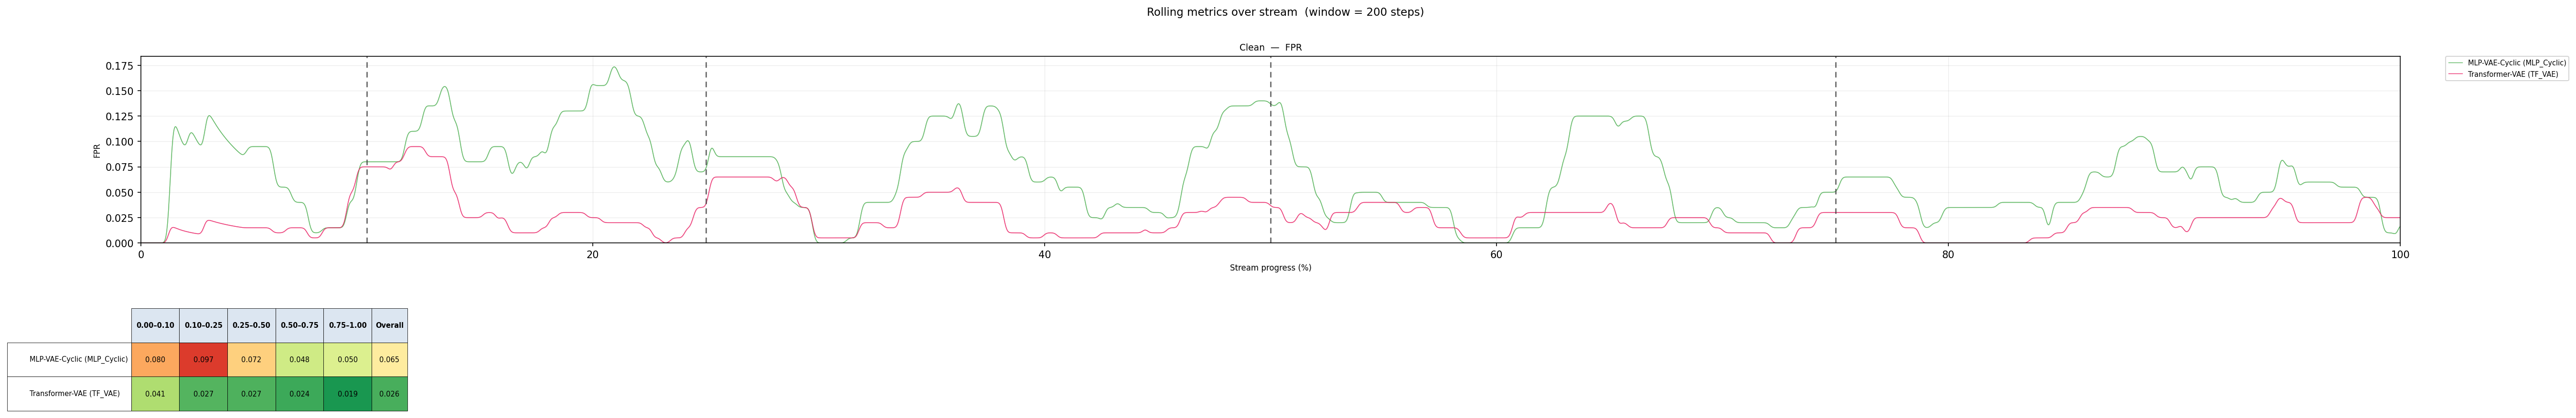

In [5]:
!python scripts/plot_fpr_over_time.py {OUTPUT_DIR}

from IPython.display import Image, display
display(Image(filename=f"{OUTPUT_DIR}/rolling_metrics.png"))

### Step 6 — Latent space: 3D UMAP colored by month

#### Same latent-space view as Case 1's Step 6, under the original config:

### Command:

In [6]:
import glob
from IPython.display import HTML, display

mlp_cyclic_html = sorted(glob.glob(
    f"{OUTPUT_DIR}/**/MLP_Cyclic/**/latent_umap_month.html", recursive=True))[0]
tf_vae_html = sorted(glob.glob(
    f"{OUTPUT_DIR}/**/TF_VAE/**/latent_umap_month.html", recursive=True))[0]

print("MLP-VAE-Cyclic — latent space (3D UMAP, colored by month):")
display(HTML(open(mlp_cyclic_html).read()))

print("Transformer-VAE — latent space (3D UMAP, colored by month):")
display(HTML(open(tf_vae_html).read()))


MLP-VAE-Cyclic — latent space (3D UMAP, colored by month):


Transformer-VAE — latent space (3D UMAP, colored by month):


## Case 1 vs Case 11 — does the config choice change the qualitative pattern?

| | Case 1 (thesis-aligned config) | Case 11 (this repo's original config) |
|---|---:|---:|
| Transformer-VAE FPR | 1.10% | 2.56% |
| MLP-VAE-Cyclic FPR | 8.13% | 6.51% |

Both configurations put Transformer-VAE **below** MLP-VAE-Cyclic on this mini dataset — the config change (`latent_dim`, `pool_latent`, KL settings, training length, ensemble metric, seed) shifted the exact magnitudes but not which architecture comes out better calibrated. That rules out the config gap as the cause of Case 1 diverging from the thesis's full-scale finding (where MLP-VAE-Cyclic is the better-calibrated one, 1.1% vs 4.4% at full scale — see the real `thesis_code` run logs).

The actual cause: this mini dataset's warmup window (~12 years) is a fraction of the full-scale warmup (~34.5 years, 302,227 rows) the thesis figure was produced from. Comparing the real thesis logs directly, MLP-VAE-Cyclic's FPR degrades roughly 7x going from full-scale to this mini-scale warmup, while Transformer-VAE's FPR actually improves roughly 4x over the same change — enough to flip which one looks better calibrated. This is a genuine effect of warmup size, not a configuration bug or an artifact of either config tested here.

## Scope of this testcase

This notebook is a diagnostic companion to Case 1, not a thesis figure reproduction. It exists to answer one question empirically: does this repo's original (pre-alignment) configuration change the qualitative outcome of the clean-baseline comparison relative to the thesis-aligned configuration?

For the configuration audit that motivated this notebook, see the commit that added `modules/original_repo_defaults.yaml` and reworked `modules/era5_common.yaml` to match `thesis_code/tests/regression/modules/era5_common.yaml`.